In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import torch
import pickle
from pathlib import Path
import numpy as np
from jarvis.utils import tqdm, array2tensor, tensor2array

from hexarena import STORE_DIR
FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from matplotlib import colormaps
pi_colors = colormaps['tab10'].colors
box_colors = ['blue', 'green', 'red']

# Load hidden Markov model results for normative policies

In [2]:
from hexarena.scripts.normative_policies import create_manager

subject_id = 'viktor'
manager = create_manager(subject_id)

n_actions = 4

In [3]:
with open(STORE_DIR/f'{subject_id}.mean.beliefs.pkl', 'rb') as f:
    saved = array2tensor(pickle.load(f))
block_infos = saved['block_infos']

In [15]:
n_policies_list = [1, 2, 3, 4, 5, 6, 7, 8]
all_keys, lls, ps_stay, ents = {}, {}, {}, {}
for n_policies in n_policies_list:
    all_keys[n_policies] = []
    lls[n_policies] = []
    ps_stay[n_policies] = []
    ents[n_policies] = []
    for key, _ in manager.completed(min_epoch=100, cond={
        'n_policies': n_policies,
    }):
        all_keys[n_policies].append(key)
        manager.setup(manager.configs[key])
        manager.load_ckpt(manager.ckpts[key])
        ll = manager.losses['val'][manager.best_epoch][0, 0].item()
        lls[n_policies].append(ll)

        log_xis = manager.log_xis
        p_stay = (torch.logsumexp(torch.diag(log_xis), dim=0)-torch.logsumexp(log_xis, dim=(0, 1))).exp().item()
        ps_stay[n_policies].append(p_stay)

        log_gammas = manager.log_gammas
        ent = -(log_gammas*log_gammas.exp()).sum().item()
        ents[n_policies].append(ent)
    lls[n_policies] = np.array(lls[n_policies])
    ps_stay[n_policies] = np.array(ps_stay[n_policies])
    ents[n_policies] = np.array(ents[n_policies])

In [16]:
p_th = 0.9

best_keys = {}
for n_policies in n_policies_list:
    mask = ps_stay[n_policies]>p_th
    if not np.any(mask):
        best_keys[n_policies] = None
        continue
    idx = mask.nonzero()[0][np.argmax(lls[n_policies][mask])].item() # most likely solution
    best_keys[n_policies] = all_keys[n_policies][idx]

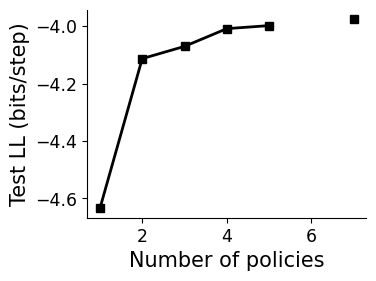

In [17]:
fig, ax = plt.subplots()
vals = []
for n_policies in n_policies_list:
    key = best_keys[n_policies]
    if key is None:
        vals.append(np.nan)
    else:
        vals.append(lls[n_policies][all_keys[n_policies].index(key)])
vals = np.array(vals)/np.log(2)
# vals = vals-vals[0]
ax.plot(
    n_policies_list, vals, marker='s', color='black',
)
# ax.set_ylim([0, None])
ax.set_ylabel('Test LL (bits/step)')
ax.set_xlabel('Number of policies')
fig.savefig(FIG_DIR/f'normative.ll_{subject_id}.svg')

In [18]:
n_policies = 2
N = n_policies

key = best_keys[n_policies]

manager.setup(manager.configs[key])
manager.load_ckpt(manager.ckpts[key])

hmp = manager.hmp
push_costs = 0.5*(torch.tanh(hmp.policies)+1).data[:, 0].numpy()

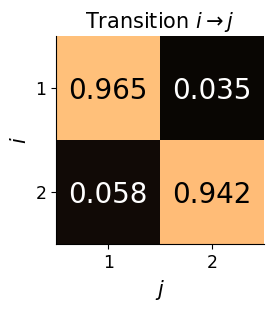

In [19]:
A = hmp.log_A.exp().data.cpu().numpy()
fig, ax = plt.subplots()
ax.imshow(A, vmin=0, vmax=1, extent=[0.5, N+0.5, N+0.5, 0.5], cmap='copper')
for i in range(N):
    for j in range(N):
        ax.text(
            j+1, i+1, '{:.3f}'.format(A[i, j]), ha='center', va='center_baseline',
            color='white' if i!=j else 'black', fontsize=40/N,
        )
ax.set_xlim([0.5, N+0.5]), ax.set_ylim([N+0.5, 0.5])
ax.set_xticks(np.arange(N)+1), ax.set_yticks(np.arange(N)+1)
ax.set_xlim([0.5, N+0.5]), ax.set_ylim([N+0.5, 0.5])
ax.set_xticks(np.arange(N)+1), ax.set_yticks(np.arange(N)+1)
ax.set_title(r'Transition $i \rightarrow j$')
ax.set_xlabel('$j$'), ax.set_ylabel('$i$')
fig.savefig(FIG_DIR/f'policy.transition_{subject_id}[N{N}].svg')

In [20]:
gammas, labels = [], []
for inputs, actions in manager.dsets['train']:
    with torch.no_grad():
        _, log_pas, log_pes, log_alphas, log_betas, log_gammas, log_xis, *_ = hmp.baum_welch(inputs[None], actions[None])
    gammas.append(log_gammas[0].exp().numpy())
    labels.append(push_costs[hmp.viterbi_trajectory(log_pes[0])])

/tmp/ipykernel_1677272/2159771387.py:14: RuntimeWarning: Mean of empty slice
  label_mean = np.nanmean(labels_all, axis=0)
/home/zheli/miniconda3/envs/cp314/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


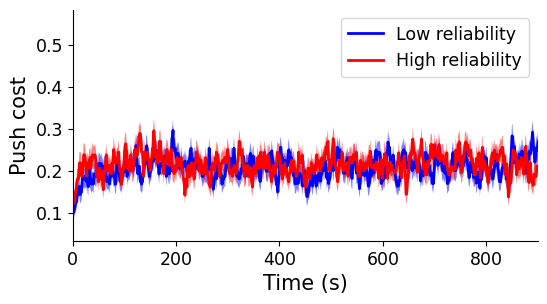

In [21]:
n_steps = max([len(labels[i]) for i in range(len(labels))])+1

_, ax = plt.subplots(figsize=(6, 3))
lines = []
for k, color in enumerate(['blue', 'red']):
    labels_all = []
    for i, block_id in enumerate(manager.block_ids['train']):
        if (k==0 and block_infos[block_id]['kappa']==0.01) or (k==1 and block_infos[block_id]['kappa']>0.01):
            labels_all.append(np.concat([labels[i], np.full((n_steps-len(labels[i]),), fill_value=np.nan)]))
    labels_all = np.stack(labels_all)

    counts = (~np.isnan(labels_all)).sum(axis=0)
    mask = counts>0.1*len(labels_all)
    label_mean = np.nanmean(labels_all, axis=0)
    label_err = np.nanstd(labels_all, axis=0)/counts**0.5

    h, = ax.plot(np.arange(n_steps), label_mean, color=color)
    lines.append(h)
    ax.fill_between(np.arange(n_steps), label_mean-label_err, label_mean+label_err, color=color, edgecolor='none', alpha=0.5)
ax.legend(lines, ['Low reliability', 'High reliability'])
ax.set_xlim([0, 900])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Push cost')
plt.show()

('20230215', 7)


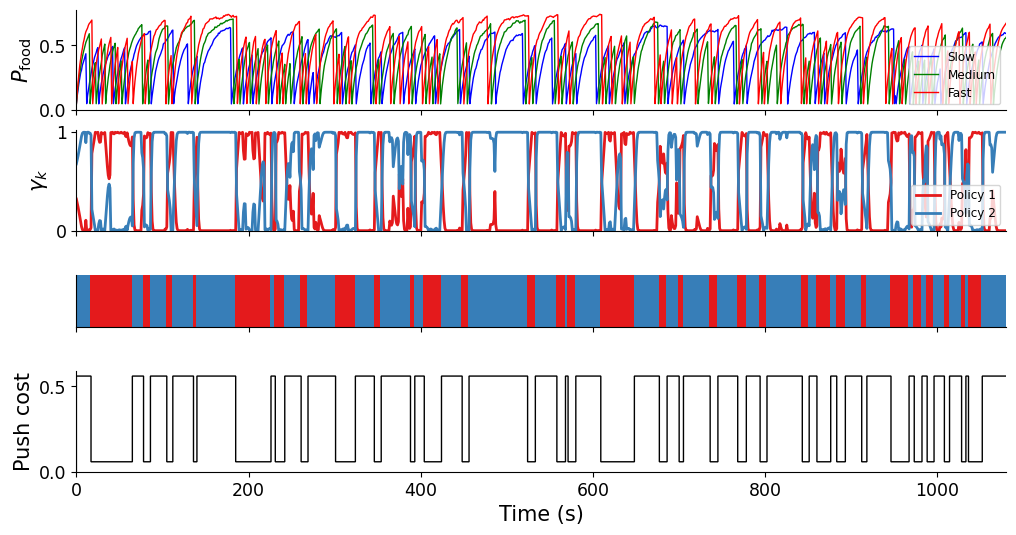

In [22]:
from matplotlib.colors import ListedColormap
pi_colors = colormaps['Set1'].colors

i = rng.choice(len(manager.block_ids['train']))
if subject_id=='marco':
    i = 2
# if subject_id=='viktor':
#     i = 132
print(manager.block_ids['train'][i])
inputs, actions = manager.dsets['train'][i]
beliefs = (torch.tanh(inputs)+1)/2

with torch.no_grad():
    _, log_pas, log_pes, log_alphas, log_betas, log_gammas, log_xis, *_ = hmp.baum_welch(inputs[None], actions[None])
gammas = log_gammas[0].exp()
labels = hmp.viterbi_trajectory(log_pes[0])

fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
ax = axes[0]
lines = []
for i, color in enumerate(['blue', 'green', 'red']):
    h, = ax.plot(beliefs[:, i], color=color, linewidth=1)
    lines.append(h)
ax.legend(lines, ['Slow', 'Medium', 'Fast'], loc='lower right', fontsize='xx-small')
ax.set_ylim([0, None])
ax.set_ylabel(r'$P_\mathrm{food}$')
ax = axes[1]
lines = []
for i, color in enumerate(pi_colors[:N]):
    h, = ax.plot(gammas[:, i], color=color)
    lines.append(h)
ax.legend(lines, [f'Policy {i+1}' for i in range(N)], loc='lower right', fontsize='xx-small')
ax.set_ylim([0, 1.02])
ax.set_ylabel(r'$\gamma_k$')
ax = axes[2]
ax.imshow(labels[None], aspect=60, vmin=0, vmax=n_policies-1, cmap=ListedColormap(pi_colors[:N]))
ax.set_yticks([])
ax = axes[3]
ax.stairs(push_costs[labels], color='black')
ax.set_ylabel('Push cost')
ax.set_xlim([0, 1080])
ax.set_xlabel('Time (s)')
fig.savefig(FIG_DIR/f'normative.policies_{subject_id}[N{N}].svg')

In [23]:
xs = torch.cat([inputs for inputs, _ in manager.dsets['train']])
idxs = rng.choice(len(xs), 2000, replace=False)
xs = xs[idxs]
coords = torch.tanh(xs)/2+0.5

with torch.no_grad():
    _, log_pas = hmp.action_probs(xs[None])
vals = log_pas[0].exp()

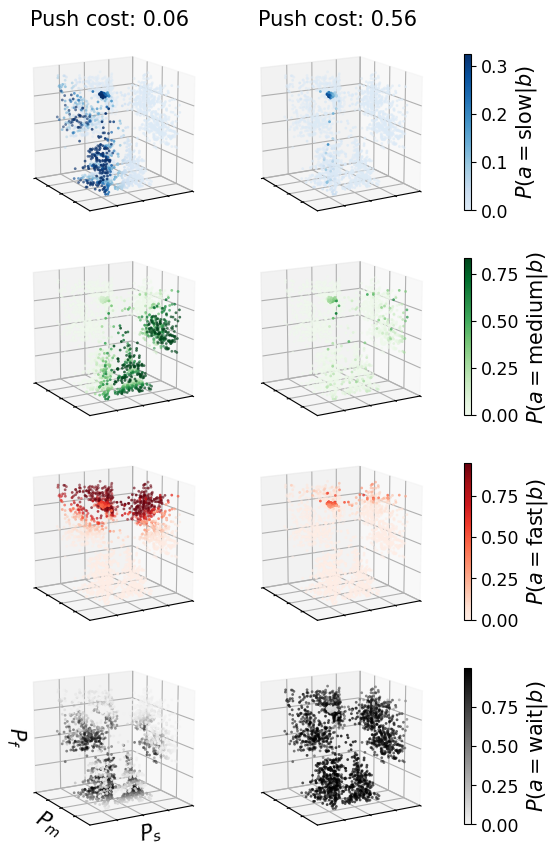

In [24]:
fig = plt.figure(figsize=(2.5*N, 9))
margin, gap = 0.05, 0.01
width = (1-2*margin-(N-1)*gap)/N
height = (1-2*margin-(n_actions-1)*gap)/n_actions
axes = np.empty((n_actions, N), dtype=object)
labelpad = -12
cmaps = ['Blues', 'Greens', 'Reds', 'gray_r']
a_names = ['slow', 'medium', 'fast', 'wait']
for j in range(n_actions):
    cmap = cmaps[j]
    for i in range(N):
        ax = fig.add_axes(
            [0.2*margin+(width+gap)*i, margin+(height+gap)*(n_actions-j-1), width, height],
            projection='3d', elev=15, azim=60,
        )
        vmin = -0.05
        vmax = np.quantile(vals[..., j], 0.95)
        h = ax.scatter(
            coords[:, 0], coords[:, 1], coords[:, 2], s=4,
            c=vals[:, i, j], cmap=cmap, edgecolor='none',
            vmin=vmin, vmax=vmax,
        )
        ax_lim = [0, 0.8]
        ax.set_xlim(ax_lim), ax.set_ylim(ax_lim), ax.set_zlim(ax_lim)
        ax.set_aspect('equal')
        ax_ticks = [0, 0.2, 0.4, 0.6]
        ax.set_xticks(ax_ticks), ax.set_yticks(ax_ticks), ax.set_zticks(ax_ticks)
        ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
        ax.zaxis.line.set_visible(False)
        for line in ax.zaxis.get_majorticklines():
            line.set_color('none')
        if i==0 and j==n_actions-1:
            ax.set_xlabel('$P_s$', labelpad=labelpad)
            ax.set_ylabel('$P_m$', labelpad=labelpad)
            ax.set_zlabel('$P_f$', labelpad=labelpad)
        if j==0:
            # ax.set_title(f'Policy {i+1}', fontsize='medium')
            ax.set_title('Push cost: {:.2f}'.format(push_costs[i]))
    cax = fig.add_axes([1-1.2*margin, margin+(height+gap)*(n_actions-j-1)+0.1*height, 0.3*margin, 0.8*height])
    cbar = plt.colorbar(h, cax=cax, label=r'$P(a=\mathrm{'+a_names[j]+'}|b)$')
    cax.set_ylim([0, None])
fig.savefig(FIG_DIR/f'policies.on.belief.space_{subject_id}[N{N}].svg')
# fig.savefig(FIG_DIR/f'policy.example.svg')